In [1]:
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import sys
module_path = os.path.abspath(os.path.join('../../../../../'))
if module_path not in sys.path:
    sys.path.append(module_path)
    
from data_science_utilities.models.xgb.hyperparameter_search.random_search import OptimalXGBHyperparameterSearch

In [2]:
RANDOM_SEED = 32
# RFE on the play-by-play-augmented data recommends 45 features (get_best_num_features(.005)); see rfe.ipynb
BEST_NUM_FEATS = 45
TARGET = 'target_win'

RANDOM_XGB_PARAMS = {
    # How fast the model learns. The smaller, the more likely to get stuck in local minima, but the larger, the more likely to overshoot the global minima
    'learning_rate': [.03, .05, .1, .15, .2],
    # How deep the tree can be. The deeper, the more likely to overfit and more complex
    'max_depth': [2, 3],
    # The fraction of samples to be used for fitting the individual base learners. 
    # Values lower than 1 make the model more robust by preventing overfitting
    'subsample': [.5, .7, .9],
    # The minimum number of samples required to be at a leaf node. The larger, the more conservative
    'min_child_weight': [10, 20, 50, 100],
    # Minimum loss reduction required to make a split on a leaf node of the tree. Attempts to only split when it makes a significant improvement
    'gamma': [.5, 1, 5, 10, 100],
    # The number of trees to be used in the model. The more, the more likely to overfit
    'n_estimators': [10, 20,30, 40, 50],
    # The number of iterations the model can't improve before stopping
    'early_stopping_rounds': [10, 20, 50],
    # The way the model calculates the importance of each feature. Total gain is the sum of the gain of each feature used in the model
    'importance_type': ['total_gain'],
    # The evaluation metric to be used. AUC measures how well the model is able to distinguish between classes (win or loss)
    'eval_metric': ['auc']
}

RANDOM_SEARCH_PARAMS = dict(
    n_iter=100,
    cv=5,
    n_jobs=-1,
    random_state=RANDOM_SEED,
    scoring='roc_auc',
)

BEST_FEATS_FROM_RFE = list(pd.read_csv(
    '../../../../../data/predict_games/model_features_in/rfe_features_kfolds.csv',
    index_col=0
).loc[BEST_NUM_FEATS, :].dropna().values)

MODEL_INPUTS_DF = pd.read_parquet(
    '../../../../../data/predict_games/input_data/schedule_and_weekly.parquet'
)

MODEL_INPUTS_DF = MODEL_INPUTS_DF.sample(
    frac=1, random_state=RANDOM_SEED
).reset_index(drop=True)

np.random.seed(RANDOM_SEED)

In [3]:
# Two-season holdout: train on everything before 2022, use 2022-2023 as the early-stopping
# test slice, and hold out 2024+2025 (the original 3-way split shifted one year forward).
train_df = MODEL_INPUTS_DF[(MODEL_INPUTS_DF['season'] < 2022)]
test_df = MODEL_INPUTS_DF[
    (MODEL_INPUTS_DF['season'] >= 2022) & (MODEL_INPUTS_DF['season'] < 2024)
]
holdout_df = MODEL_INPUTS_DF[MODEL_INPUTS_DF['season'] >= 2024].copy()
X_train = train_df[BEST_FEATS_FROM_RFE]
y_train = train_df[TARGET]
X_test = test_df[BEST_FEATS_FROM_RFE]
y_test = test_df[TARGET]
X_holdout = holdout_df[BEST_FEATS_FROM_RFE]
y_holdout = holdout_df[TARGET]

In [4]:
rand_hyperparam_search = OptimalXGBHyperparameterSearch(
    X_train, y_train, X_test, y_test
)

In [5]:
rand_search = rand_hyperparam_search.search(
    RANDOM_XGB_PARAMS, **RANDOM_SEARCH_PARAMS
)

[0]	validation_0-auc:0.63650	validation_1-auc:0.62271
[1]	validation_0-auc:0.65999	validation_1-auc:0.62762
[2]	validation_0-auc:0.67290	validation_1-auc:0.63825
[0]	validation_0-auc:0.63891	validation_1-auc:0.59625
[3]	validation_0-auc:0.68267	validation_1-auc:0.65317
[0]	validation_0-auc:0.63113	validation_1-auc:0.60475
[1]	validation_0-auc:0.66489	validation_1-auc:0.63429
[4]	validation_0-auc:0.68440	validation_1-auc:0.65604
[0]	validation_0-auc:0.62832	validation_1-auc:0.61219
[2]	validation_0-auc:0.66938	validation_1-auc:0.64479
[5]	validation_0-auc:0.68533	validation_1-auc:0.65494
[1]	validation_0-auc:0.65067	validation_1-auc:0.61961
[1]	validation_0-auc:0.66040	validation_1-auc:0.62585
[6]	validation_0-auc:0.68873	validation_1-auc:0.65553
[3]	validation_0-auc:0.67468	validation_1-auc:0.64677
[2]	validation_0-auc:0.67424	validation_1-auc:0.64525
[2]	validation_0-auc:0.67412	validation_1-auc:0.62600
[3]	validation_0-auc:0.68141	validation_1-auc:0.65313
[7]	validation_0-auc:0.69055

[34]	validation_0-auc:0.72461	validation_1-auc:0.65466
[29]	validation_0-auc:0.68975	validation_1-auc:0.65463
[26]	validation_0-auc:0.68848	validation_1-auc:0.65845
[39]	validation_0-auc:0.69529	validation_1-auc:0.65427
[26]	validation_0-auc:0.71036	validation_1-auc:0.65461
[42]	validation_0-auc:0.69672	validation_1-auc:0.65323
[33]	validation_0-auc:0.72868	validation_1-auc:0.64786
[30]	validation_0-auc:0.69001	validation_1-auc:0.65451
[35]	validation_0-auc:0.72489	validation_1-auc:0.65438
[27]	validation_0-auc:0.68850	validation_1-auc:0.65822
[40]	validation_0-auc:0.69537	validation_1-auc:0.65371
[43]	validation_0-auc:0.69700	validation_1-auc:0.65229
[34]	validation_0-auc:0.72967	validation_1-auc:0.64747
[36]	validation_0-auc:0.72489	validation_1-auc:0.65438
[28]	validation_0-auc:0.68977	validation_1-auc:0.65923
[31]	validation_0-auc:0.69073	validation_1-auc:0.65708
[41]	validation_0-auc:0.69594	validation_1-auc:0.65356
[44]	validation_0-auc:0.69735	validation_1-auc:0.65236
[35]	valid

[32]	validation_0-auc:0.69747	validation_1-auc:0.65943
[24]	validation_0-auc:0.69351	validation_1-auc:0.65772
[32]	validation_0-auc:0.71362	validation_1-auc:0.65703
[30]	validation_0-auc:0.69712	validation_1-auc:0.65404
[28]	validation_0-auc:0.69686	validation_1-auc:0.65394
[1]	validation_0-auc:0.66009	validation_1-auc:0.62698
[22]	validation_0-auc:0.69398	validation_1-auc:0.65845
[33]	validation_0-auc:0.69767	validation_1-auc:0.65899
[25]	validation_0-auc:0.69398	validation_1-auc:0.65885
[31]	validation_0-auc:0.69755	validation_1-auc:0.65438
[29]	validation_0-auc:0.69741	validation_1-auc:0.65465
[33]	validation_0-auc:0.71450	validation_1-auc:0.65754
[2]	validation_0-auc:0.67068	validation_1-auc:0.64165
[34]	validation_0-auc:0.69798	validation_1-auc:0.65907
[26]	validation_0-auc:0.69395	validation_1-auc:0.65951
[32]	validation_0-auc:0.69811	validation_1-auc:0.65487
[30]	validation_0-auc:0.69777	validation_1-auc:0.65533
[0]	validation_0-auc:0.63981	validation_1-auc:0.62346
[3]	validatio

[14]	validation_0-auc:0.68532	validation_1-auc:0.64990
[23]	validation_0-auc:0.63074	validation_1-auc:0.61881
[22]	validation_0-auc:0.63559	validation_1-auc:0.61404
[6]	validation_0-auc:0.63449	validation_1-auc:0.60909
[6]	validation_0-auc:0.64912	validation_1-auc:0.62838
[23]	validation_0-auc:0.64624	validation_1-auc:0.62632
[7]	validation_0-auc:0.67393	validation_1-auc:0.64690
[17]	validation_0-auc:0.65431	validation_1-auc:0.63582
[22]	validation_0-auc:0.64290	validation_1-auc:0.63105
[15]	validation_0-auc:0.68653	validation_1-auc:0.65027
[23]	validation_0-auc:0.63559	validation_1-auc:0.61404
[24]	validation_0-auc:0.63111	validation_1-auc:0.62011
[7]	validation_0-auc:0.64912	validation_1-auc:0.62838
[7]	validation_0-auc:0.64172	validation_1-auc:0.62056
[24]	validation_0-auc:0.64624	validation_1-auc:0.62632
[7]	validation_0-auc:0.67033	validation_1-auc:0.64570
[23]	validation_0-auc:0.64290	validation_1-auc:0.63105
[18]	validation_0-auc:0.65431	validation_1-auc:0.63582
[16]	validation_

[27]	validation_0-auc:0.66109	validation_1-auc:0.63815
[7]	validation_0-auc:0.65118	validation_1-auc:0.62698
[16]	validation_0-auc:0.69014	validation_1-auc:0.65097
[15]	validation_0-auc:0.69099	validation_1-auc:0.64937
[4]	validation_0-auc:0.65434	validation_1-auc:0.63295
[5]	validation_0-auc:0.66456	validation_1-auc:0.63706
[24]	validation_0-auc:0.65539	validation_1-auc:0.63956
[6]	validation_0-auc:0.65666	validation_1-auc:0.63233
[8]	validation_0-auc:0.68086	validation_1-auc:0.64587
[21]	validation_0-auc:0.65657	validation_1-auc:0.63714
[28]	validation_0-auc:0.66109	validation_1-auc:0.63815
[8]	validation_0-auc:0.65425	validation_1-auc:0.63044
[7]	validation_0-auc:0.67946	validation_1-auc:0.64794
[5]	validation_0-auc:0.65933	validation_1-auc:0.63781
[16]	validation_0-auc:0.69271	validation_1-auc:0.64903
[6]	validation_0-auc:0.66479	validation_1-auc:0.63939
[25]	validation_0-auc:0.65539	validation_1-auc:0.63956
[7]	validation_0-auc:0.65670	validation_1-auc:0.63215
[22]	validation_0-au

...

[46]	validation_0-auc:0.71271	validation_1-auc:0.65535


[47]	validation_0-auc:0.71322	validation_1-auc:0.65626


[48]	validation_0-auc:0.71322	validation_1-auc:0.65626


[49]	validation_0-auc:0.71322	validation_1-auc:0.65626




Best parameters found:  {'subsample': 0.9, 'n_estimators': 50, 'min_child_weight': 50, 'max_depth': 2, 'learning_rate': 0.2, 'importance_type': 'total_gain', 'gamma': 10, 'eval_metric': 'auc', 'early_stopping_rounds': 20}


Best score found:  0.6853882904954804


Best Selected Features:  ['off_opp_sack_yards_cumulative_average_rank', 'target_def_cumulative_avg_points_allowed_rank', 'def_opp_rushing_yards_cumulative_average_rank', 'opp_def_cumulative_avg_points_allowed_rank', 'is_home_target', 'off_opp_success_rate_competitive_cumulative_average_rank', 'def_target_rushing_yards_cumulative_average_rank', 'off_opp_proe_competitive_cumulative_average_rank', 'off_target_rush_success_rate_competitive_cumulative_average_rank', 'def_target_sack_yards_cumulative_average_rank_change', 'off_target_interceptions_cumulative_average_rank', 'def_opp_attempts', 'opp_off_cumulative_avg_score_rank', 'off_opp_epa_per_play_garbage_leading_cumulative_average_rank', 'off_opp_passing_epa', 'off_target_earl

In [6]:
# view all the scores from the search
rand_search.cv_results_

{'mean_fit_time': array([0.1954711 , 0.22825079, 0.19575076, 0.20001998, 0.22656527,
        0.07856841, 0.11859641, 0.10156865, 0.17095375, 0.17903805,
        0.07709513, 0.07733359, 0.18654003, 0.1670002 , 0.21544309,
        0.11775451, 0.11028991, 0.12358761, 0.11264625, 0.0882462 ,
        0.07881613, 0.11887555, 0.16579113, 0.16794639, 0.15943494,
        0.23814435, 0.11699519, 0.11309171, 0.16337171, 0.16769032,
        0.15021958, 0.25190387, 0.12759967, 0.20252166, 0.09153252,
        0.08417096, 0.11824765, 0.1678237 , 0.08151941, 0.12207713,
        0.19078417, 0.23044658, 0.09800057, 0.11324139, 0.15379601,
        0.07914457, 0.08114266, 0.11291404, 0.14225936, 0.21042819,
        0.14722972, 0.08421793, 0.23786469, 0.07539554, 0.19217491,
        0.11705956, 0.23263688, 0.07911   , 0.19232879, 0.1020987 ,
        0.15620074, 0.14970403, 0.08491607, 0.08414702, 0.12123885,
        0.14917879, 0.1010695 , 0.12051921, 0.15153937, 0.21749139,
        0.15442104, 0.12319121,

<Axes: >

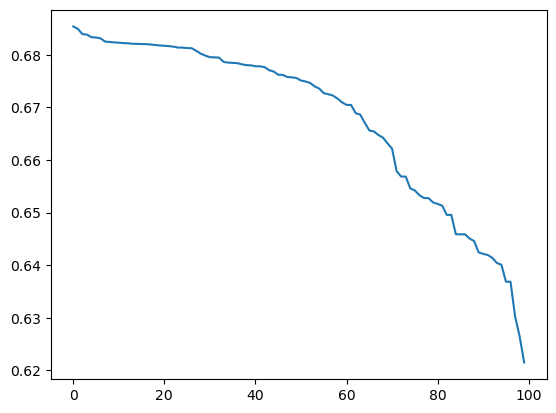

In [7]:
# Graph the search results. Make the index the rank of the score
# another column for the mean test score
rand_search_results = pd.DataFrame(rand_search.cv_results_)
rand_search_results['rank_test_score'] = rand_search_results['rank_test_score']
rand_search_results['mean_test_score'] = rand_search_results['mean_test_score']
rand_search_results = rand_search_results.sort_values(by='rank_test_score', ascending=True)
rand_search_results = rand_search_results.reset_index(drop=True)
rand_search_results['mean_test_score'].plot()

In [8]:
# What are the grid search params for the top 5 scores?
rand_search_results.head(5)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_subsample,param_n_estimators,param_min_child_weight,param_max_depth,param_learning_rate,param_importance_type,...,param_early_stopping_rounds,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.196662,0.023574,0.002472,0.000073,0.9,50,50,2,0.2,total_gain,...,20,"{'subsample': 0.9, 'n_estimators': 50, 'min_ch...",0.686134,0.687067,0.672904,0.682338,0.698498,0.685388,0.008251,1
1,0.195751,0.011101,0.003459,0.000743,0.9,40,50,3,0.2,total_gain,...,50,"{'subsample': 0.9, 'n_estimators': 40, 'min_ch...",0.679474,0.688079,0.676208,0.681776,0.699157,0.684939,0.008101,2
2,0.202522,0.014779,0.004128,0.001745,0.9,40,100,3,0.15,total_gain,...,50,"{'subsample': 0.9, 'n_estimators': 40, 'min_ch...",0.678094,0.685629,0.678604,0.683348,0.693999,0.683935,0.005780,3
3,0.199223,0.013621,0.002650,0.000234,0.9,40,100,2,0.1,total_gain,...,20,"{'subsample': 0.9, 'n_estimators': 40, 'min_ch...",0.686589,0.677682,0.675559,0.683711,0.695649,0.683838,0.007121,4
4,0.251904,0.011442,0.003627,0.001051,0.7,50,20,3,0.1,total_gain,...,50,"{'subsample': 0.7, 'n_estimators': 50, 'min_ch...",0.678832,0.673468,0.682125,0.681296,0.701018,0.683348,0.009338,5


In [9]:
# save the json of the best model
best_model = rand_search.best_estimator_
best_model.save_model(
    os.path.join(module_path, 'models', 'best_random_xgb_model.json')
)

In [10]:
# What is the score on the holdout set?
best_model.score(X_holdout, y_holdout)

0.6470588235294118

In [11]:
holdout_df.loc[:, 'preds'] = best_model.predict_proba(X_holdout)[:, 1]

In [12]:
# Show the predictions for the holdout set
results_df = holdout_df[
    ['game_id', 'week', 'target_team', 'opp_team', 'target_win', 'preds']
].copy()
results_df.sort_values(by='game_id', inplace=True)
results_df.reset_index(drop=True, inplace=True)
results_df

,game_id,week,target_team,opp_team,target_win,preds
0,2024_01_ARI_BUF,1,ARI,BUF,0,0.186479
1,2024_01_ARI_BUF,1,BUF,ARI,1,0.804295
2,2024_01_BAL_KC,1,KC,BAL,1,0.637099
3,2024_01_BAL_KC,1,BAL,KC,0,0.431604
4,2024_01_CAR_NO,1,CAR,NO,0,0.211920
...,...,...,...,...,...,...
1083,2025_18_SEA_SF,18,SF,SEA,0,0.549297
1084,2025_18_TEN_JAX,18,JAX,TEN,1,0.822657
1085,2025_18_TEN_JAX,18,TEN,JAX,0,0.172437
1086,2025_18_WAS_PHI,18,PHI,WAS,0,0.771134


week
1     0.890625
2     0.646484
3     0.524414
4     0.652344
5     0.446429
6     0.745541
7     0.843333
8     0.757432
9     0.745541
10    0.661990
11    0.771700
12    0.736626
13    0.735352
14    0.758573
15    0.801758
16    0.632812
17    0.642578
18    0.606445
dtype: float64

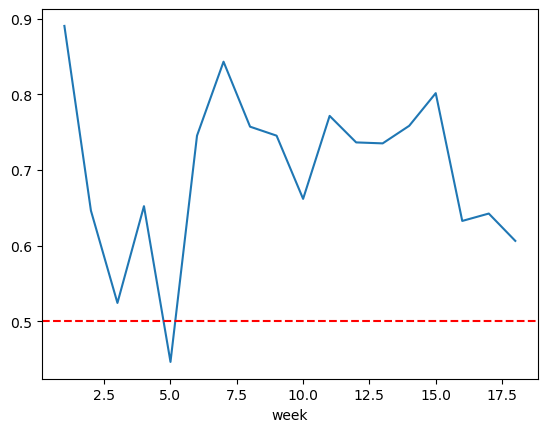

In [13]:
# get the AUROC score by week
weekly_scores = holdout_df.groupby('week').apply(
    lambda x: roc_auc_score(x['target_win'], x['preds']),
    include_groups=False
)
weekly_scores.plot()
# Place a horizontal line at .5 to show the baseline
plt.axhline(y=.5, color='r', linestyle='--')
weekly_scores

In [14]:
# for each game_id, only keep the higher prediction
higher_preds = holdout_df.groupby('game_id').apply(
    lambda x: x.loc[x['preds'].idxmax(), :],
    include_groups=False
)
higher_preds.reset_index(drop=True, inplace=True)

week
1     0.868571
2     0.635628
3     0.550781
4     0.680162
5     0.403061
6     0.661111
7     0.823864
8     0.547619
9     0.644444
10    0.640625
11    0.650000
12    0.500000
13    0.613636
14    0.638158
15    0.657005
16    0.678431
17    0.545833
18    0.615686
dtype: float64

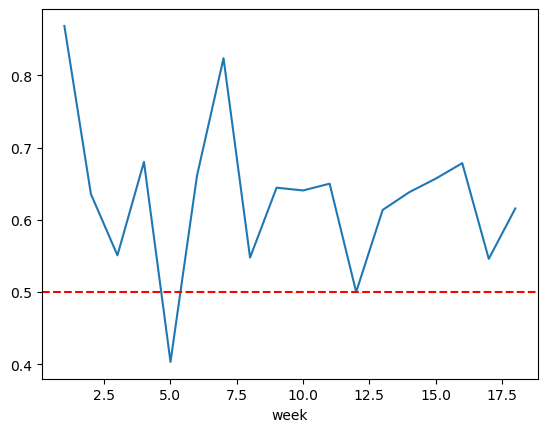

In [15]:
# get the AUROC score by week
weekly_scores = higher_preds.groupby('week').apply(
    lambda x: roc_auc_score(x['target_win'], x['preds']),
    include_groups=False
)
weekly_scores.plot()
# Place a horizontal line at .5 to show the baseline
plt.axhline(y=.5, color='r', linestyle='--')
weekly_scores

## How good are the model's *confident* predictions?

AUROC only measures **ranking** (can the model sort winners above losers?). It says
nothing about whether a 0.80 prediction is actually right ~80% of the time. The cells
below answer "when the model has a strong prediction, how well does it predict?" using:

1. **Brier score & log loss** — residual-based metrics that penalize overconfidence.
2. **Confidence-bucketed accuracy** — the direct answer: how often the favored team wins,
   grouped by how sure the model was.
3. **Reliability diagram** — visual calibration check (predicted prob vs observed win rate).

Note: `holdout_df` has two rows per `game_id` (one per team). Brier/log loss are computed
on all rows consistently; the bucketed-accuracy table uses the one-row-per-game `higher_preds`
frame so each game is counted once.

In [16]:
# Residual-based metrics. Unlike AUROC, these penalize confident-and-wrong predictions.
from sklearn.metrics import brier_score_loss, log_loss

brier = brier_score_loss(holdout_df['target_win'], holdout_df['preds'])
ll = log_loss(holdout_df['target_win'], holdout_df['preds'])
print(f"Brier score: {brier:.4f}  (lower is better; 0.25 = coin flip)")
print(f"Log loss:    {ll:.4f}  (lower is better; punishes confident-and-wrong hardest)")

Brier score: 0.2206  (lower is better; 0.25 = coin flip)
Log loss:    0.6309  (lower is better; punishes confident-and-wrong hardest)


In [17]:
# Confidence-bucketed accuracy: the direct answer to "when the model is confident, is it right?"
# On higher_preds, `preds` is the model's confidence in its pick (0.5-1.0) and
# target_win == 1 means the favored team actually won.
higher_preds['confidence'] = higher_preds['preds']
higher_preds['bucket'] = pd.cut(
    higher_preds['confidence'], bins=[0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
)

confidence_summary = higher_preds.groupby('bucket', observed=True).agg(
    n_games=('target_win', 'size'),
    pick_accuracy=('target_win', 'mean'),   # how often the favored team won
    avg_confidence=('confidence', 'mean'),  # what the model claimed
)
# Positive gap = overconfident (claimed more than it delivered)
confidence_summary['calibration_gap'] = (
    confidence_summary['avg_confidence'] - confidence_summary['pick_accuracy']
)
confidence_summary

,n_games,pick_accuracy,avg_confidence,calibration_gap
bucket,,,,
"(0.5, 0.6]",217,0.571429,0.553390,-0.018039
"(0.6, 0.7]",168,0.696429,0.646469,-0.049959
"(0.7, 0.8]",110,0.727273,0.741961,0.014689
"(0.8, 0.9]",17,1.000000,0.826227,-0.173773


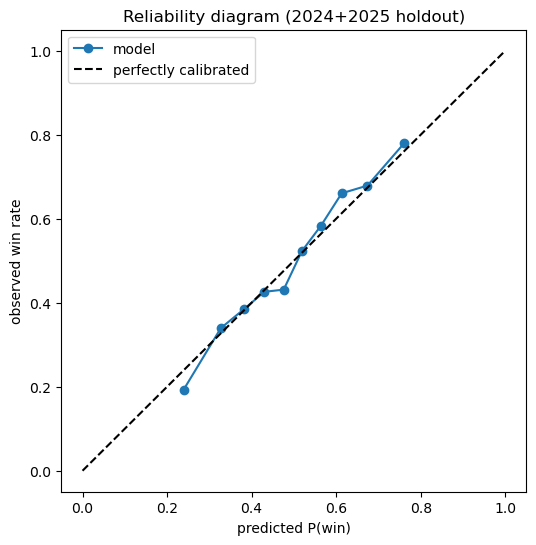

In [18]:
# Reliability diagram: are the probabilities trustworthy?
# Points on the diagonal = perfectly calibrated. Below the diagonal on the right
# side = the model is overconfident when bullish.
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(
    holdout_df['target_win'], holdout_df['preds'], n_bins=10, strategy='quantile'
)
plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker='o', label='model')
plt.plot([0, 1], [0, 1], 'k--', label='perfectly calibrated')
plt.xlabel('predicted P(win)')
plt.ylabel('observed win rate')
plt.title('Reliability diagram (2024+2025 holdout)')
plt.legend()
plt.show()

## Does a wider home-vs-away gap mean better predictions?

Each game has two predictions: `P(home wins)` from the home-perspective row and
`P(away wins)` from the away-perspective row. The **gap** between them is a stronger
confidence signal than `max(pred)` alone — it uses *both* perspectives. A wide gap
means the two views agree strongly on a winner; a narrow gap means the model is torn.

Hypothesis: when the gap is wide, accuracy should be higher. We pivot the two rows onto
one row per game (via `is_home_target`), define the model's pick as whichever side has
the higher probability, and bucket accuracy by gap width (quintiles, so every bin is
populated).

In [19]:
# Pivot the two perspectives of each game onto one row (is_home_target: 1 = home, 0 = away)
game_view = holdout_df.pivot_table(
    index='game_id', columns='is_home_target', values=['preds', 'target_win'], aggfunc='first'
).dropna()

games = pd.DataFrame({
    'home_pred': game_view[('preds', 1)],
    'away_pred': game_view[('preds', 0)],
    'home_won':  game_view[('target_win', 1)].astype(int),
})
games['gap']           = games['home_pred'] - games['away_pred']   # >0 leans home, <0 leans away
games['abs_gap']       = games['gap'].abs()                        # strength of the lean
games['pred_home_win'] = games['home_pred'] > games['away_pred']
games['correct']       = games['pred_home_win'] == (games['home_won'] == 1)

# Bucket by gap width (quintiles) and measure accuracy in each
games['gap_quintile'] = pd.qcut(games['abs_gap'], 5)
gap_summary = games.groupby('gap_quintile', observed=True).agg(
    n_games=('correct', 'size'),
    mean_abs_gap=('abs_gap', 'mean'),
    accuracy=('correct', 'mean'),
)
print(f"Overall correlation(abs_gap, correct): {games['abs_gap'].corr(games['correct'].astype(int)):.3f}")
gap_summary

Overall correlation(abs_gap, correct): 0.206


,n_games,mean_abs_gap,accuracy
gap_quintile,,,
"(-0.000851, 0.0875]",109,0.040279,0.513761
"(0.0875, 0.178]",109,0.132918,0.596330
"(0.178, 0.276]",108,0.225485,0.638889
"(0.276, 0.421]",109,0.343179,0.678899
"(0.421, 0.727]",109,0.518990,0.788991


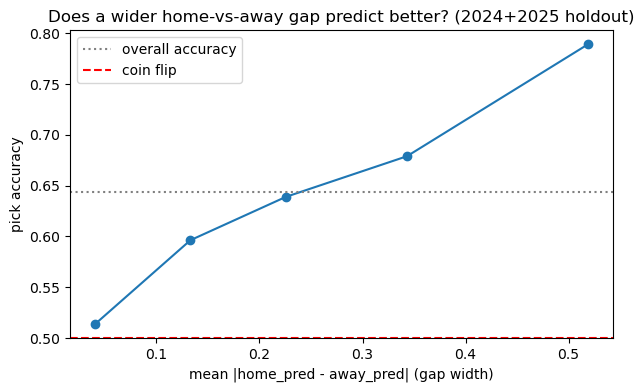

In [20]:
# Visualize the hypothesis: accuracy should rise as the home-vs-away gap widens
plt.figure(figsize=(7, 4))
plt.plot(gap_summary['mean_abs_gap'], gap_summary['accuracy'], marker='o')
plt.axhline(y=games['correct'].mean(), color='gray', linestyle=':', label='overall accuracy')
plt.axhline(y=0.5, color='r', linestyle='--', label='coin flip')
plt.xlabel('mean |home_pred - away_pred| (gap width)')
plt.ylabel('pick accuracy')
plt.title('Does a wider home-vs-away gap predict better? (2024+2025 holdout)')
plt.legend()
plt.show()